In [10]:
import os
import pandas as pd
import sys
import numpy as np
import glob

In [11]:
pista_dataset = r"/home/Senthilkumar/project_files/Image_classification/All_datasets/Pistachio_Image_Dataset/Pistachio_Image_Dataset"

In [17]:
image_labels = {}
for filepath in glob.glob(os.path.join(pista_dataset,"**","*.jpg"), recursive=True):
    image_labels[filepath] = os.path.basename(os.path.dirname(filepath))
pista_df = pd.DataFrame(image_labels.items(), columns=['filepath','label'])
pista_df.head()

,filepath,label
0,/home/meduser@quest-global.com/Senthilkumar/pr...,Siirt_Pistachio
1,/home/meduser@quest-global.com/Senthilkumar/pr...,Siirt_Pistachio
2,/home/meduser@quest-global.com/Senthilkumar/pr...,Siirt_Pistachio
3,/home/meduser@quest-global.com/Senthilkumar/pr...,Siirt_Pistachio
4,/home/meduser@quest-global.com/Senthilkumar/pr...,Siirt_Pistachio


In [38]:
from matplotlib import pyplot as plt
%matplotlib inline
plt.style.use("seaborn-v0_8")

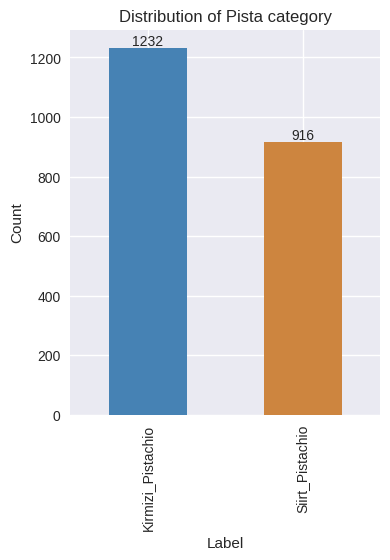

In [39]:
fig, axs = plt.subplots(figsize=(4,5))
color=['steelblue', 'peru']
ax = pista_df['label'].value_counts().plot.bar(color=color, xlabel="Label", ylabel="Count", title="Distribution of Pista category")
for container in ax.containers:
    ax.bar_label(container)

In [42]:
from sklearn.model_selection import train_test_split
x, y = pista_df['filepath'], pista_df['label']
x_train, x_val, y_train, y_val = train_test_split(x, y, test_size=0.15, random_state=42, stratify=y)
x_train, x_test, y_train, y_test = train_test_split(x_train, y_train, test_size=0.10, random_state=42, stratify=y_train)
print(x_train, y_train)
print(x_val, y_val)
print(x_test, y_test)

1939    /home/meduser@quest-global.com/Senthilkumar/pr...
776     /home/meduser@quest-global.com/Senthilkumar/pr...
1443    /home/meduser@quest-global.com/Senthilkumar/pr...
834     /home/meduser@quest-global.com/Senthilkumar/pr...
1684    /home/meduser@quest-global.com/Senthilkumar/pr...
                              ...                        
209     /home/meduser@quest-global.com/Senthilkumar/pr...
2108    /home/meduser@quest-global.com/Senthilkumar/pr...
1875    /home/meduser@quest-global.com/Senthilkumar/pr...
1828    /home/meduser@quest-global.com/Senthilkumar/pr...
1213    /home/meduser@quest-global.com/Senthilkumar/pr...
Name: filepath, Length: 1642, dtype: object 1939    Kirmizi_Pistachio
776       Siirt_Pistachio
1443    Kirmizi_Pistachio
834       Siirt_Pistachio
1684    Kirmizi_Pistachio
              ...        
209       Siirt_Pistachio
2108    Kirmizi_Pistachio
1875    Kirmizi_Pistachio
1828    Kirmizi_Pistachio
1213    Kirmizi_Pistachio
Name: label, Length: 1642, dtype

In [48]:
pista_train = pd.DataFrame(columns=['filepath', 'label'])
pista_train['filepath'] = x_train
pista_train['label'] = y_train
pista_train.reset_index(drop=True, inplace=True)

pista_val = pd.DataFrame(columns=['filepath', 'label'])
pista_val['filepath'] = x_val
pista_val['label'] = y_val
pista_val.reset_index(drop=True, inplace=True)

pista_test = pd.DataFrame(columns=['filepath', 'label'])
pista_test['filepath'] = x_test
pista_test['label'] = y_test
pista_test.reset_index(drop=True, inplace=True)
pista_test.head()

,filepath,label
0,/home/meduser@quest-global.com/Senthilkumar/pr...,Kirmizi_Pistachio
1,/home/meduser@quest-global.com/Senthilkumar/pr...,Siirt_Pistachio
2,/home/meduser@quest-global.com/Senthilkumar/pr...,Kirmizi_Pistachio
3,/home/meduser@quest-global.com/Senthilkumar/pr...,Siirt_Pistachio
4,/home/meduser@quest-global.com/Senthilkumar/pr...,Kirmizi_Pistachio


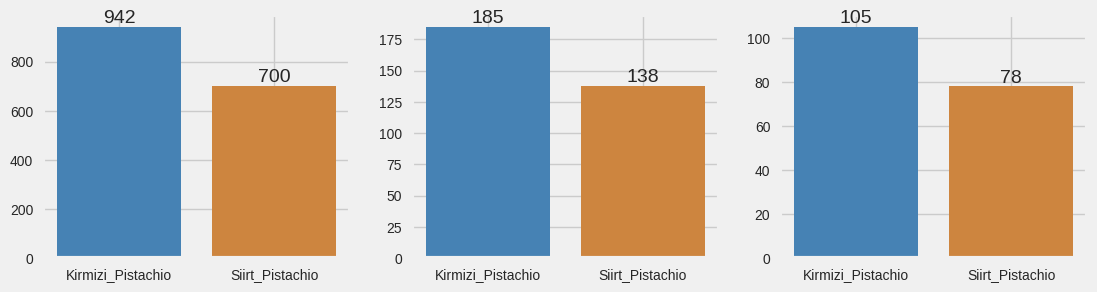

In [83]:
fig, axs = plt.subplots(1,3, figsize = (12,3))
colors=['steelblue', 'peru']
train_count, val_count, test_count = pista_train['label'].value_counts(), pista_val['label'].value_counts(), pista_test['label'].value_counts()
for ax, count in zip(axs, [train_count, val_count, test_count]):
    # ax.set_xlabel("label")
    container = ax.bar(count.index, count.values, color=colors,)
    ax.bar_label(container, count.values)

In [55]:
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler, random_split
from torchvision import models, transforms
from PIL import Image
import cv2

In [65]:
class Pista_Dataset(Dataset):
    def __init__(self, dataframe, feature_transform=None, target_transform=None):
        self.filepath = dataframe['filepath']
        self.label = dataframe['label']
        self.feature_transform = feature_transform
        self.target_transform = target_transform

    def __getitem__(self, idx):
        img = Image.open(self.filepath[idx])
        label = self.label[idx]
        
        category = sorted(self.label.unique())
        
        if self.feature_transform:
            img = self.feature_transform(img)
        if self.target_transform:
            label = self.target_transform(label, category)
        return img, label

    def __len__(self):
        return len(self.filepath)

In [66]:
def binary_encoding(label, category):
    """
    Encodes for Binary Classification
    label : string
    category : sorted list of labels
    """
    encoded_label = torch.FloatTensor([category.index(label)])
    return encoded_label

def nonbinary_encoding(label, category):
    """
    Encodes for Multi Class Classification
    label : string
    category : sorted list of labels
    One hot encoding ex.: label='category1', categories=['category0', 'category1', 'category2'], return=[0, 1, 0].
    """
    encoded_label = torch.zeros(len(category))
    index = category.index(label)
    encoded_label[index]=1
    return encoded_label

def make_balanced_sampler(y):
    """
    Generates weighted sampler based on the distribution of target label
    y : Pandas series or Tensor
    Generally used for imbalanced dataset
    """
    import pandas
    import torch
    torch.set_printoptions(precision=5)
    if isinstance(y, pandas.core.series.Series):
        y = (y.apply(lambda x: binary_encoding(x, sorted(y.unique())))).astype(float)
        y = torch.tensor(y)
        classes, counts = y.unique(return_counts=True)
    elif isinstance(y, torch.Tensor):
        classes, counts = y.unique(return_counts=True)
    else:
        print("Something wrong happend")
    weights = 1.0 / counts.float()
    sample_weights = weights[y.squeeze().long()]
    print(y[:10])
    print(sample_weights[:10])
    # Builds sampler with compute weights
    generator = torch.Generator()
    sampler = WeightedRandomSampler(
        weights=sample_weights,
        num_samples=len(sample_weights),
        generator=generator,
        replacement=True
    )
    return sampler

In [67]:
train_transform = transforms.Compose([transforms.RandomResizedCrop(224),
                                      transforms.RandomHorizontalFlip(),
                                      # transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
                                      transforms.ToTensor()
                                    ])
valid_transform = transforms.Compose([transforms.Resize(256),
                                      transforms.CenterCrop(224),
                                      # transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
                                      transforms.ToTensor()
                                     
                                     ])
test_transform = transforms.Compose([transforms.Resize(256),
                                    transforms.CenterCrop(224),
                                     # transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
                                     transforms.ToTensor(),
                                      
                                     ])

In [69]:
train_dataset = Pista_Dataset(pista_train, feature_transform=train_transform, target_transform=binary_encoding)
val_dataset = Pista_Dataset(pista_val, feature_transform=valid_transform, target_transform=binary_encoding)
test_dataset = Pista_Dataset(pista_test, feature_transform=test_transform, target_transform=binary_encoding)
val_dataset[0][0].numpy()

array([[[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]]], dtype=float32)

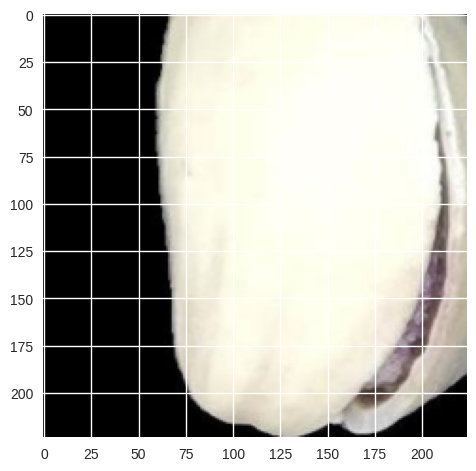

In [71]:
temp_image = train_dataset[0][0].numpy()
temp_image = temp_image.transpose((1,2,0))

plt.imshow(temp_image)

In [72]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=False, sampler=make_balanced_sampler(pista_train['label']))
# train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

tensor([0., 1., 0., 1., 0., 0., 1., 0., 0., 1.], dtype=torch.float64)
tensor([0.00106, 0.00143, 0.00106, 0.00143, 0.00106, 0.00106, 0.00143, 0.00106,
        0.00106, 0.00143])


In [73]:
img, labl = next(iter(val_loader))
img.shape

torch.Size([32, 3, 224, 224])

In [74]:
from StepbyStep import StepByStep
from Classification_Models import classification_model
from torch import optim
vgg16_model, resnet50_model, mobilenet_model = classification_model(1)

/home/meduser@quest-global.com/Senthilkumar/ENVS/Gen_AI_310/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/meduser@quest-global.com/Senthilkumar/ENVS/Gen_AI_310/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)
/home/meduser@quest-global.com/Senthilkumar/ENVS/Gen_AI_310/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to g

classifier.0.weight
classifier.0.bias
classifier.3.weight
classifier.3.bias
classifier.6.weight
classifier.6.bias


In [75]:
for param in vgg16_model.parameters():
    print(param.requires_grad)

False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
True
True
True
True
True
True


In [76]:
model = vgg16_model

loss_fn = nn.BCEWithLogitsLoss(reduction='mean')
# multi_loss_fn = nn.CrossEntropyLoss(reduction='mean')
new_optimizer = optim.Adam(model.parameters(), lr=3e-4)

sbs_cnn2 = StepByStep(model, loss_fn, new_optimizer)
sbs_cnn2.set_loaders(train_loader, val_loader)
sbs_cnn2.train(10)

1/10, train_loss = 0.5712696102519448, val_loss=0.29221218011595984
2/10, train_loss = 0.397897612876617, val_loss=0.20187067714604465
3/10, train_loss = 0.35901818653711903, val_loss=0.32967816113325005
4/10, train_loss = 0.3557551530404733, val_loss=0.18882032145153393
5/10, train_loss = 0.3009655077296954, val_loss=0.21170972287654877
6/10, train_loss = 0.2599286186293914, val_loss=0.18798346897925844
7/10, train_loss = 0.27007687722261137, val_loss=0.1888405873694203
8/10, train_loss = 0.3107281350172483, val_loss=0.18279654972932555
9/10, train_loss = 0.23925508171893084, val_loss=0.28766870413991535
10/10, train_loss = 0.23076848012323564, val_loss=0.17428710108453577


In [77]:
result = sbs_cnn2.loader_apply(test_loader, sbs_cnn2.correct)
result

tensor([[ 95, 105],
        [ 77,  78]])

In [78]:
result[:,0]/result[:, 1]

tensor([0.90476, 0.98718])

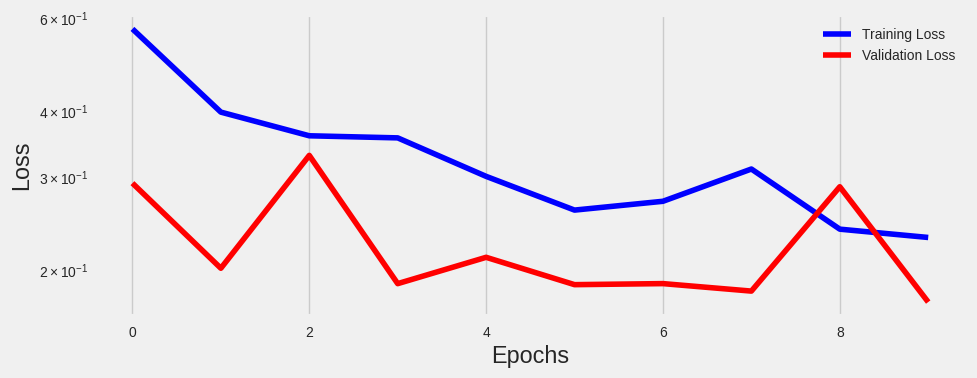

In [79]:
sbs_cnn2.plot_losses()

In [80]:
sbs_cnn2.save_checkpoint("Pista_Classifier")

In [81]:
sbs_cnn2.count_parameters()

119549953

In [84]:
torch.cuda.empty_cache()